# 04 — EDA: Demand over Time

**Student:** Nosirov Nodir  
**Group:** Tulpar

This notebook studies trend and seasonality in weekly FOODS demand. All analytical decisions use the **training period only**. Validation and test targets are not loaded, which protects the final evaluation from information leakage.

## 1. Load only training observations

The processed Parquet data is filtered before loading. Only week and demand columns are needed for this short analysis.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import pyarrow.dataset as pads
from IPython.display import display

pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

def find_project_root():
    candidates = [Path.cwd(), Path.cwd().parent, Path("/content/retail-demand-forecasting")]
    for candidate in candidates:
        if (candidate / "data" / "processed" / "m5_foods_weekly").exists():
            return candidate.resolve()
    raise FileNotFoundError("Processed FOODS data was not found. Run notebooks 01 and 02 first.")

PROJECT_ROOT = find_project_root()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed" / "m5_foods_weekly"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_DIR.mkdir(exist_ok=True)
dataset = pads.dataset(PROCESSED_DIR, format="parquet")
train_filter = pads.field("dataset_split") == "train"
train_table = dataset.to_table(columns=["week_start", "weekly_units_sold"], filter=train_filter)

print("Train rows loaded:", f"{train_table.num_rows:,}")
print("Validation/test targets loaded: no")

Train rows loaded: 3,003,902
Validation/test targets loaded: no


## 2. Weekly trend

Total demand can grow when more products become active, so the table includes both total units and mean units per active series. A four-week moving average makes the general direction easier to see. It is used only for EDA, not yet as a model feature.

In [2]:
weekly_train = train_table.group_by("week_start").aggregate([
    ("weekly_units_sold", "sum"),
    ("weekly_units_sold", "mean"),
    ("weekly_units_sold", "count"),
    ("weekly_units_sold", "min"),
    ("weekly_units_sold", "max"),
]).to_pandas().rename(columns={
    "weekly_units_sold_sum": "total_units",
    "weekly_units_sold_mean": "mean_units_per_active_series",
    "weekly_units_sold_count": "active_series",
    "weekly_units_sold_min": "minimum_series_units",
    "weekly_units_sold_max": "maximum_series_units",
}).sort_values("week_start").reset_index(drop=True)
weekly_train["total_units_ma4"] = weekly_train["total_units"].rolling(window=4, min_periods=4).mean()
weekly_train["mean_units_ma4"] = weekly_train["mean_units_per_active_series"].rolling(window=4, min_periods=4).mean()
weekly_train["year"] = weekly_train["week_start"].dt.year
weekly_train["month"] = weekly_train["week_start"].dt.month

display(weekly_train.head(8))
display(weekly_train.tail(8))

,week_start,total_units,mean_units_per_active_series,active_series,minimum_series_units,maximum_series_units,total_units_ma4,mean_units_ma4,year,month
0,2011-01-31,145851,25.25,5777,0,2211,NaN,NaN,2011,1
1,2011-02-07,141740,23.98,5910,0,923,NaN,NaN,2011,2
2,2011-02-14,120641,20.08,6007,0,725,NaN,NaN,2011,2
3,2011-02-21,114126,18.63,6127,0,651,"130,589.50",21.99,2011,2
4,2011-02-28,130587,20.81,6274,0,722,"126,773.50",20.88,2011,2
5,2011-03-07,128823,20.26,6358,0,723,"123,544.25",19.95,2011,3
6,2011-03-14,122932,19.13,6427,0,723,"124,117.00",19.71,2011,3
7,2011-03-21,111979,17.31,6469,0,750,"123,580.25",19.38,2011,3


,week_start,total_units,mean_units_per_active_series,active_series,minimum_series_units,maximum_series_units,total_units_ma4,mean_units_ma4,year,month
261,2016-02-01,196176,13.65,14368,0,765,"184,197.00",12.82,2016,2
262,2016-02-08,207012,14.41,14370,0,716,"187,901.00",13.08,2016,2
263,2016-02-15,198657,13.82,14370,0,725,"193,236.00",13.45,2016,2
264,2016-02-22,178807,12.44,14370,0,836,"195,163.00",13.58,2016,2
265,2016-02-29,199561,13.89,14370,0,719,"196,009.25",13.64,2016,2
266,2016-03-07,202687,14.10,14370,0,818,"194,928.00",13.56,2016,3
267,2016-03-14,193108,13.44,14370,0,694,"193,540.75",13.47,2016,3
268,2016-03-21,195565,13.61,14370,0,887,"197,730.25",13.76,2016,3


## 3. Month and year patterns

Month statistics compare the mean demand per active store-product series. Year statistics show how the general demand level and active assortment changed during the training history.

In [3]:
month_names = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
monthly_train = weekly_train.groupby("month", as_index=False).agg(
    observed_weeks=("week_start", "size"),
    mean_units_per_active_series=("mean_units_per_active_series", "mean"),
    mean_total_weekly_units=("total_units", "mean"),
    mean_active_series=("active_series", "mean"),
)
monthly_train["month_name"] = monthly_train["month"].map(month_names)

yearly_train = weekly_train.groupby("year", as_index=False).agg(
    observed_weeks=("week_start", "size"),
    mean_units_per_active_series=("mean_units_per_active_series", "mean"),
    mean_total_weekly_units=("total_units", "mean"),
    mean_active_series=("active_series", "mean"),
)

display(monthly_train)
display(yearly_train)

,month,observed_weeks,mean_units_per_active_series,mean_total_weekly_units,mean_active_series,month_name
0,1,22,15.41,"164,934.68","11,295.18",Jan
1,2,25,15.85,"166,018.04","11,063.08",Feb
2,3,25,15.28,"163,216.28","11,160.08",Mar
3,4,22,15.46,"157,792.32","10,574.05",Apr
4,5,21,14.99,"153,984.86","10,652.52",May
5,6,22,15.78,"170,964.32","11,218.55",Jun
6,7,22,16.06,"171,307.41","11,006.82",Jul
7,8,22,15.84,"170,435.77","11,152.77",Aug
8,9,22,15.61,"172,892.14","11,418.09",Sep
9,10,22,15.26,"163,788.95","11,165.00",Oct


,year,observed_weeks,mean_units_per_active_series,mean_total_weekly_units,mean_active_series
0,2011,48,18.40,"129,767.21","7,072.02"
1,2012,53,18.34,"165,977.55","9,091.66"
2,2013,52,15.24,"172,487.08","11,336.44"
3,2014,52,13.14,"172,399.00","13,141.27"
4,2015,52,12.19,"172,933.85","14,179.33"
5,2016,12,13.34,"191,733.25","14,368.42"


## 4. Visual analysis

The first chart compares raw weekly totals with the four-week moving average. The other charts compare demand per active series, which reduces distortion from changes in the number of available products.

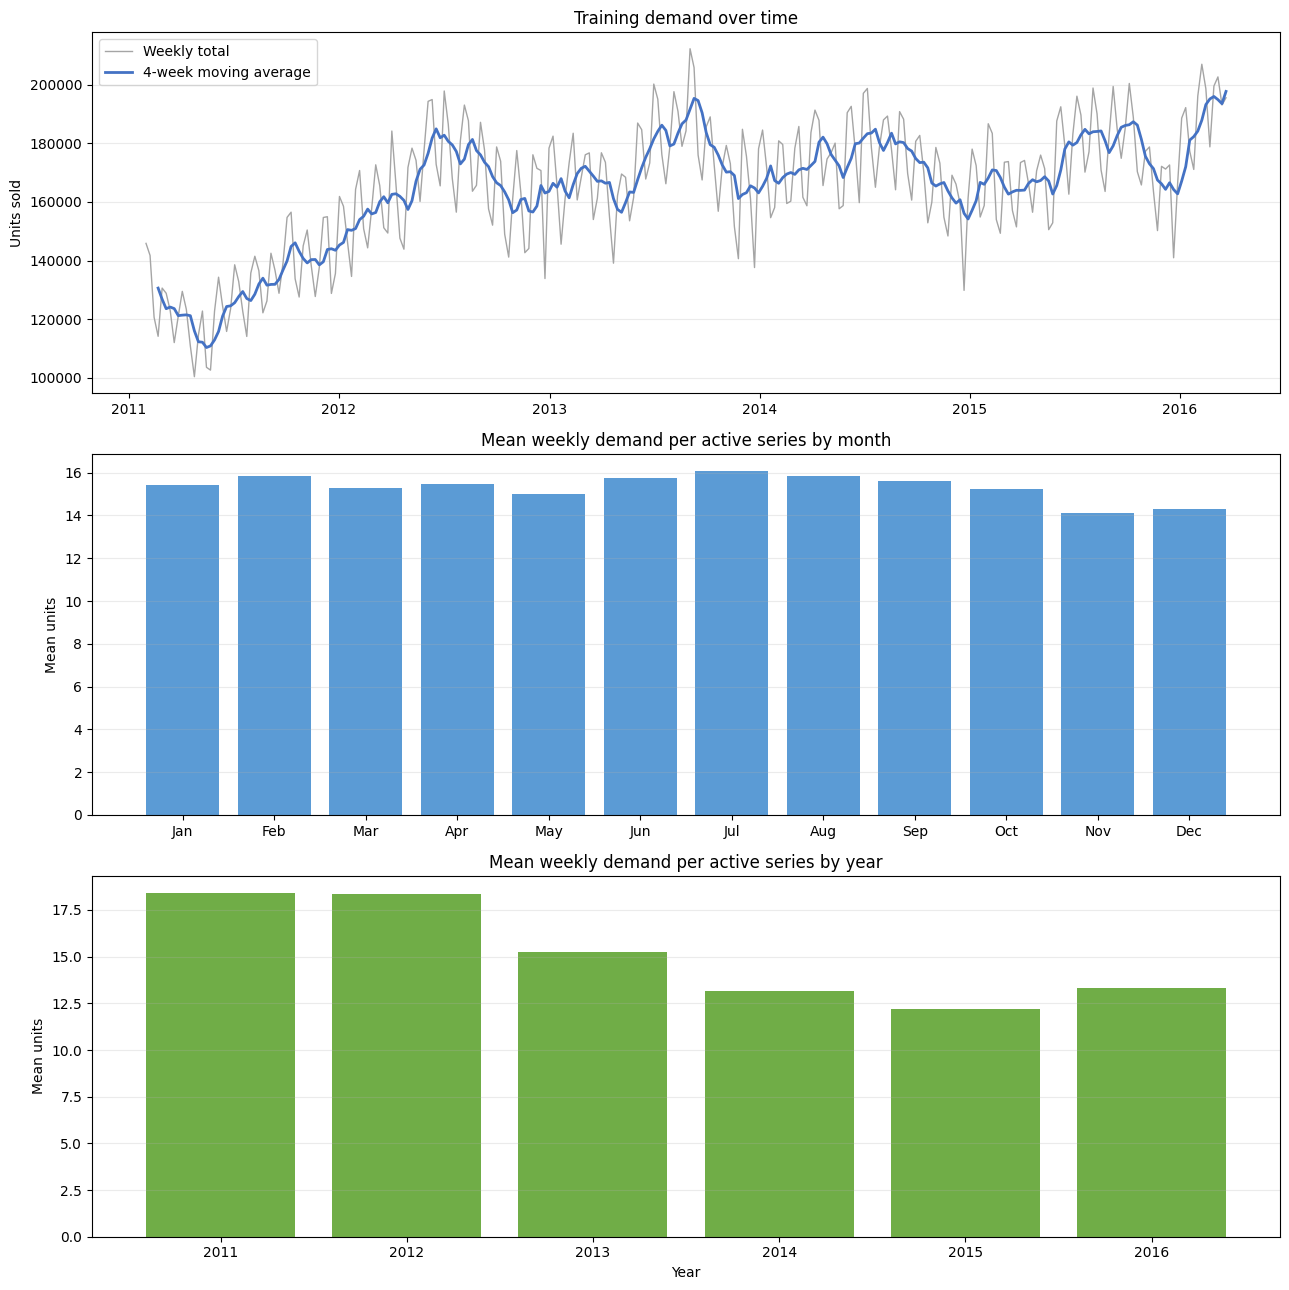

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 13))

axes[0].plot(weekly_train["week_start"], weekly_train["total_units"], color="#A5A5A5", linewidth=1, label="Weekly total")
axes[0].plot(weekly_train["week_start"], weekly_train["total_units_ma4"], color="#4472C4", linewidth=2, label="4-week moving average")
axes[0].set_title("Training demand over time")
axes[0].set_ylabel("Units sold")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.25)

axes[1].bar(monthly_train["month_name"], monthly_train["mean_units_per_active_series"], color="#5B9BD5")
axes[1].set_title("Mean weekly demand per active series by month")
axes[1].set_ylabel("Mean units")
axes[1].grid(axis="y", alpha=0.25)

axes[2].bar(yearly_train["year"].astype(str), yearly_train["mean_units_per_active_series"], color="#70AD47")
axes[2].set_title("Mean weekly demand per active series by year")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Mean units")
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

## 5. Reproducible findings

The following values are calculated from training data instead of written manually. They identify the strongest and weakest seasonal months, peak and low weeks, and the change between the beginning and end of the training history.

In [5]:
strongest_month = monthly_train.loc[monthly_train["mean_units_per_active_series"].idxmax()]
weakest_month = monthly_train.loc[monthly_train["mean_units_per_active_series"].idxmin()]
peak_week = weekly_train.loc[weekly_train["total_units"].idxmax()]
lowest_week = weekly_train.loc[weekly_train["total_units"].idxmin()]
first_eight_mean = weekly_train.head(8)["mean_units_per_active_series"].mean()
last_eight_mean = weekly_train.tail(8)["mean_units_per_active_series"].mean()
change_pct = 100 * (last_eight_mean - first_eight_mean) / first_eight_mean

findings = pd.DataFrame([
    {"finding": "strongest_month", "value": strongest_month["month_name"], "supporting_metric": strongest_month["mean_units_per_active_series"]},
    {"finding": "weakest_month", "value": weakest_month["month_name"], "supporting_metric": weakest_month["mean_units_per_active_series"]},
    {"finding": "peak_total_demand_week", "value": str(peak_week["week_start"].date()), "supporting_metric": peak_week["total_units"]},
    {"finding": "lowest_total_demand_week", "value": str(lowest_week["week_start"].date()), "supporting_metric": lowest_week["total_units"]},
    {"finding": "first_to_last_8_week_mean_change_pct", "value": "percent", "supporting_metric": change_pct},
])
display(findings)

,finding,value,supporting_metric
0,strongest_month,Jul,16.06
1,weakest_month,Nov,14.11
2,peak_total_demand_week,2013-09-02,"212,307.00"
3,lowest_total_demand_week,2011-04-25,"100,337.00"
4,first_to_last_8_week_mean_change_pct,percent,-33.90


## 6. Save and verify reports

Only small aggregated reports are saved in Git. The processed row-level dataset remains local.

In [6]:
assert train_table.num_rows == 3_003_902
assert weekly_train["week_start"].max() == pd.Timestamp("2016-03-21")
assert weekly_train["week_start"].is_monotonic_increasing
assert len(monthly_train) == 12
assert not weekly_train[["total_units", "mean_units_per_active_series", "active_series"]].isna().any().any()
assert weekly_train["total_units_ma4"].isna().sum() == 3

weekly_train.to_csv(REPORT_DIR / "eda_time_weekly_train.csv", index=False)
monthly_train.to_csv(REPORT_DIR / "eda_time_monthly_train.csv", index=False)
yearly_train.to_csv(REPORT_DIR / "eda_time_yearly_train.csv", index=False)
findings.to_csv(REPORT_DIR / "eda_time_findings.csv", index=False)

print("EDA-2 train-only checks passed.")
print("Training weeks:", len(weekly_train))
print("Latest analyzed target week starts:", weekly_train["week_start"].max().date())
print("Validation/test targets were not loaded.")

EDA-2 train-only checks passed.
Training weeks: 269
Latest analyzed target week starts: 2016-03-21
Validation/test targets were not loaded.


## 7. Initial interpretation

Training demand changes over time and differs by calendar month. The number of active series also grows during early history, so total sales alone can be misleading. Later models should include time features and past-sales lags, while validation and test remain chronological and separate.